# 06 - Resultados finales

Acá junto las figuras que mejor cuentan el trabajo y agrego un ejemplo completo con una
muestra que nunca participó del entrenamiento. Las conclusiones más fuertes quedan en
fondo/dron; modelo y modo se muestran con sus límites.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

RAIZ = Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent

ID_CORRIDA = "dronerf_demo_v2_final_n1024_hann_b20_seed42"
CARPETA_CORRIDA = RAIZ / "results" / "runs" / ID_CORRIDA
FIGURAS = RAIZ / "results" / "figures"
FIGURAS_CORRIDA = CARPETA_CORRIDA / "figuras"


## Doce figuras elegidas

La secuencia va de verificaciones controladas a datos reales y termina con el caso
Phantom. En las figuras de tiempo, FFT y Welch aparece primero la vista completa y
después el zoom necesario para leer el detalle.


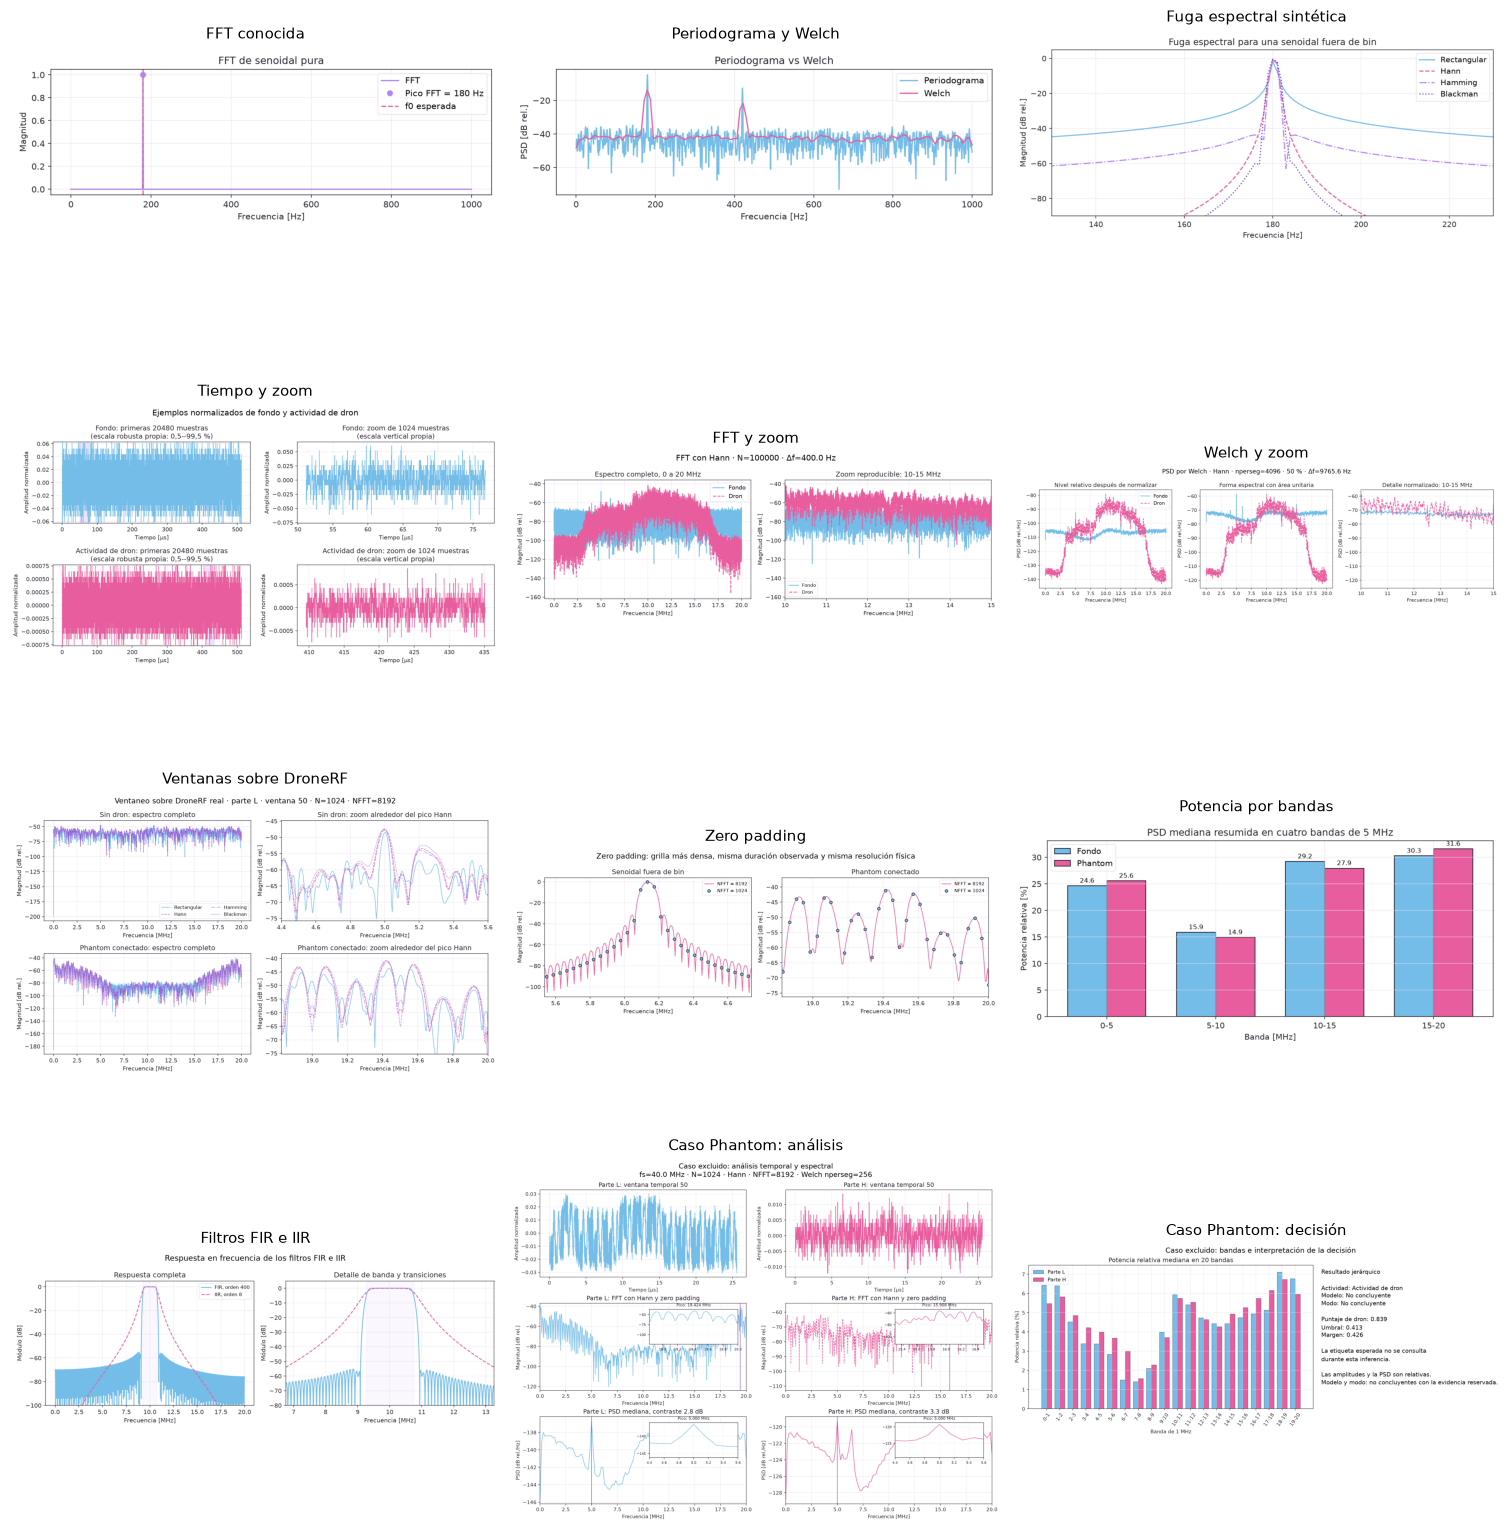

In [2]:
figuras = [
    ("FFT conocida", FIGURAS / "nb00_senoidal_fft.png"),
    ("Periodograma y Welch", FIGURAS / "nb00_periodograma_vs_welch.png"),
    ("Fuga espectral sintética", FIGURAS / "nb03_ventanas_fuga_espectral.png"),
    ("Tiempo y zoom", FIGURAS / "nb02_tiempo_fondo_vs_dron.png"),
    ("FFT y zoom", FIGURAS / "nb02_fft_fondo_vs_dron.png"),
    ("Welch y zoom", FIGURAS / "nb02_welch_fondo_vs_dron.png"),
    ("Ventanas sobre DroneRF", FIGURAS / "nb03_ventanas_dronerf.png"),
    ("Zero padding", FIGURAS / "nb03_zero_padding.png"),
    ("Potencia por bandas", FIGURAS / "nb03_potencia_relativa_bandas.png"),
    ("Filtros FIR e IIR", FIGURAS / "nb04_respuesta_filtros.png"),
    ("Caso Phantom: análisis", FIGURAS_CORRIDA / "07_caso_phantom_analisis_aps.png"),
    ("Caso Phantom: decisión", FIGURAS_CORRIDA / "08_caso_phantom_decision.png"),
]

faltantes = [ruta for _, ruta in figuras if not ruta.exists()]
if faltantes:
    raise FileNotFoundError(f"Faltan figuras finales: {faltantes}")

fig, ejes = plt.subplots(4, 3, figsize=(15, 16), constrained_layout=True)
for eje, (titulo, ruta) in zip(ejes.ravel(), figuras, strict=True):
    eje.imshow(plt.imread(ruta))
    eje.set_title(titulo, fontsize=10.5)
    eje.axis("off")

ruta_montaje = RAIZ / "output" / "figuras_finales_12.png"
fig.savefig(ruta_montaje, dpi=170, bbox_inches="tight", facecolor="white")
plt.show()


## Caso excluido: muestra que luego se revela como Phantom conectado

La entrada se procesó sin consultar su etiqueta. Primero se calcularon ventanas, FFT,
Welch, características y decisión de actividad. Recién después se leyó el catálogo separado para
comparar la salida con la respuesta esperada. Modelo y modo solo se muestran si superaron
la política conservadora basada en evaluación reservada.


In [3]:
ruta_caso = CARPETA_CORRIDA / "metricas" / "caso_phantom_conectado.json"
caso = json.loads(ruta_caso.read_text(encoding="utf-8-sig"))
inferencia = caso["inference_before_label"]
esperado = caso["expected_after_inference"]

tabla_decision = pd.DataFrame(
    [
        {
            "nivel": "Actividad",
            "propuesto": inferencia["state"],
            "esperado": esperado["activity"],
        },
        {
            "nivel": "Modelo",
            "propuesto": inferencia["model"],
            "esperado": esperado["model"],
        },
        {
            "nivel": "Modo",
            "propuesto": inferencia["mode"],
            "esperado": esperado["mode"],
        },
    ]
)
display(tabla_decision)
print(f"Puntaje de dron = {inferencia['drone_score']:.3f}")
print(f"Umbral = {inferencia['threshold']:.3f}")
print(f"Margen de actividad = {inferencia['margin']:.3f}")
print(f"Margen de modelo = {inferencia['model_margin']:.3f}")


,nivel,propuesto,esperado
0,Actividad,dron,dron
1,Modelo,NaN,phantom
2,Modo,NaN,conectado


Puntaje de dron = 0.839
Umbral = 0.413
Margen de actividad = 0.426
Margen de modelo = 0.053


In [4]:
tabla_caracteristicas = pd.read_csv(
    CARPETA_CORRIDA / "tablas" / "caso_phantom_caracteristicas.csv"
)
columnas = [
    "part",
    "rms",
    "pico",
    "factor_cresta",
    "frecuencia_pico_fft_hz",
    "centroide_espectral_hz",
    "ancho_banda_espectral_hz",
    "piso_psd_db_rel",
    "contraste_pico_piso_db",
]
display(tabla_caracteristicas[columnas].round(4))


,part,rms,pico,factor_cresta,frecuencia_pico_fft_hz,centroide_espectral_hz,ancho_banda_espectral_hz,piso_psd_db_rel,contraste_pico_piso_db
0,H,0.0033,0.0120,3.3530,1.590820e+07,1.065737e+07,6.230281e+06,-122.4879,3.2580
1,L,0.0004,0.0016,3.4491,1.942383e+07,1.082381e+07,6.202922e+06,-139.4660,2.8197


 para esta muestra el puntaje de actividad supera el umbral. El ranking
interno pone Phantom primero, pero la aplicación deja modelo y modo como `No concluyente`
porque la evaluación reservada no respaldó esa etapa.

 la decisión combina varias medidas temporales y espectrales de
100 ventanas L y 100 H, no un único pico. El piso y el contraste son relativos a señales
normalizadas.

 la coincidencia posterior de Phantom no transforma esa hipótesis en una
identificación validada. El resultado defendible de este caso es actividad de dron.


## Auditoría de robustez y regla de seguridad

La calibración final se prueba sin volver a ajustar modelos ni umbrales: validación
anidada, etiquetas permutadas, ruido, cuantización, tramos temporales y partes L/H.


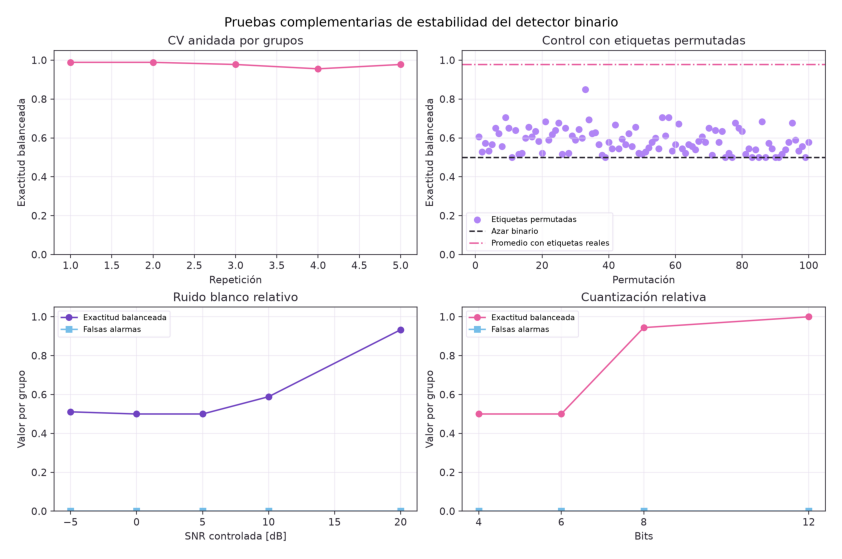

,partes,balanced_accuracy,false_alarm_count,missed_drone_count
0,L,1.000000,0,0
1,H,0.611111,2,1
2,L_H,1.000000,0,0


,partes,coverage,false_alarm_count
0,L,0.0,0
1,H,0.0,0
2,L_H,1.0,0


,segment,prediction,drone_score,threshold
0,21,fondo,0.266,0.413
1,22,fondo,0.317,0.413
2,23,fondo,0.295,0.413
3,24,fondo,0.315,0.413
4,25,fondo,0.305,0.413


,control,estado,distancia_dominio,limite_dominio,compatible
0,ruido_blanco,no_concluyente,92.592,45.448,False
1,tono_1_mhz,no_concluyente,9122.256,45.448,False
2,tono_10_5_mhz,no_concluyente,10794.289,45.448,False
3,dos_tonos,no_concluyente,5875.719,45.448,False
4,am_10_5_mhz,no_concluyente,5124.877,45.448,False
5,chirp_4_a_16_mhz,no_concluyente,7959.005,45.448,False


In [5]:
ruta_robustez = FIGURAS_CORRIDA / "09_auditoria_robustez_detector.png"
fig, eje = plt.subplots(figsize=(14, 7))
eje.imshow(plt.imread(ruta_robustez))
eje.axis("off")
plt.show()

tabla_partes = pd.read_csv(CARPETA_CORRIDA / "tablas" / "auditoria_robustez_partes.csv")
display(
    tabla_partes[
        ["partes", "balanced_accuracy", "false_alarm_count", "missed_drone_count"]
    ]
)

tabla_politica_partes = pd.read_csv(
    CARPETA_CORRIDA / "tablas" / "auditoria_robustez_partes_politica.csv"
)
display(tabla_politica_partes[["partes", "coverage", "false_alarm_count"]])

tabla_fondos = pd.read_csv(CARPETA_CORRIDA / "tablas" / "desafio_fondos_externos.csv")
display(tabla_fondos[["segment", "prediction", "drone_score", "threshold"]].round(3))

tabla_controles = pd.read_csv(
    CARPETA_CORRIDA / "tablas" / "controles_sinteticos_dominio.csv"
)
display(
    tabla_controles[
        ["control", "estado", "distancia_dominio", "limite_dominio", "compatible"]
    ].round(3)
)


 la primera tabla es un diagnóstico sin la política final y muestra que no
es seguro forzar el umbral L/H sobre H aislada. La segunda confirma la política actual:
con una parte sola la cobertura es cero porque la app no emite actividad. 
la entrada tiene que respetar la representación usada para calibrar. **Decisión:** con una
sola parte se muestran las curvas, pero devuelve `No concluyente`.  sigue siendo
una simulación con archivos públicos y no una detección RF operacional.

**Control extra:** ruido, tonos, AM y chirp sintéticos quedaron fuera del dominio de
características calibrado solo con desarrollo. Aunque un clasificador lineal tenga un
puntaje alto, la app no lo toma como actividad si la señal no se parece a DroneRF. Esto no
identifica la fuente desconocida: solo evita forzar una conclusión fuera del alcance de la
calibración.


## Resultado general y sensibilidad

El resultado estable es fondo frente a actividad de dron. Las cifras de modelo y modo se
mantienen para mostrar hasta dónde llegó la extensión y dónde dejó de ser confiable.


In [6]:
metricas = json.loads(
    (CARPETA_CORRIDA / "metricas" / "metricas_jerarquicas.json").read_text(
        encoding="utf-8-sig"
    )
)

filas = []
for clave, nombre in [
    ("actividad", "Fondo / dron"),
    ("modelo", "Modelo"),
    ("modo_bebop", "Modo Bebop"),
    ("modo_ar", "Modo AR"),
]:
    filas.append(
        {
            "Nivel": nombre,
            "Desarrollo": metricas["oof_development"][clave][
                "balanced_accuracy"
            ],
            "Evaluación": metricas["reserved_evaluation"][clave][
                "balanced_accuracy"
            ],
            "Cobertura": metricas["reserved_evaluation"][clave]["coverage"],
        }
    )
display(pd.DataFrame(filas).set_index("Nivel").round(3))

tabla_ruido = pd.read_csv(CARPETA_CORRIDA / "tablas" / "sensibilidad_ruido.csv")
display(tabla_ruido.round(3))


,Desarrollo,Evaluación,Cobertura
Nivel,,,
Fondo / dron,1.000,1.000,1.000
Modelo,0.583,0.167,0.556
Modo Bebop,0.250,0.000,0.500
Modo AR,0.350,0.250,0.500


,snr_db,accuracy,balanced_accuracy,f1_macro,coverage
0,-5,0.333,0.556,0.314,1.0
1,0,0.250,0.500,0.200,1.0
2,5,0.250,0.500,0.200,1.0
3,10,0.500,0.667,0.500,1.0
4,20,0.917,0.944,0.899,1.0
